In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('smart_cleaned.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])

# ============================================
# Step 1: Filter Products with min 5 interactions
# ============================================
print("Before filter:")
print(f"  Rows     : {len(df):,}")
print(f"  Products : {df['Product_ID'].nunique():,}")
print(f"  Users    : {df['User_ID'].nunique():,}")

product_counts = df['Product_ID'].value_counts()
valid_products = product_counts[product_counts >= 5].index
df = df[df['Product_ID'].isin(valid_products)]

print("\nAfter filter (>= 5 interactions):")
print(f"  Rows     : {len(df):,}")
print(f"  Products : {df['Product_ID'].nunique():,}")
print(f"  Users    : {df['User_ID'].nunique():,}")
print(f"  Avg/User : {len(df)/df['User_ID'].nunique():.1f}")
print(f"  Buy count: {(df['Behavior']=='buy').sum():,}")

# ============================================
# Step 2: Updated Scores
# ============================================
score_map = {
    'pv'  : 1,
    'fav' : 8,
    'buy' : 20
}
df['Score'] = df['Behavior'].map(score_map)

print("\nNew Score Distribution:")
print(df['Score'].value_counts())

df.to_csv('smart_filtered.csv', index=False)
print("\n✅ Saved as smart_filtered.csv!")

Before filter:
  Rows     : 1,730,592
  Products : 590,266
  Users    : 19,995

After filter (>= 5 interactions):
  Rows     : 926,439
  Products : 82,023
  Users    : 19,906
  Avg/User : 46.5
  Buy count: 21,983

New Score Distribution:
Score
1     875936
8      28520
20     21983
Name: count, dtype: int64

✅ Saved as smart_filtered.csv!


In [2]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix

df = pd.read_csv('smart_filtered.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Encode
user_encoder     = LabelEncoder()
product_encoder  = LabelEncoder()
category_encoder = LabelEncoder()

df['user_idx']     = user_encoder.fit_transform(df['User_ID'])
df['product_idx']  = product_encoder.fit_transform(df['Product_ID'])
df['category_idx'] = category_encoder.fit_transform(df['Category_ID'])

n_users    = df['user_idx'].nunique()
n_products = df['product_idx'].nunique()

# User-Item Matrix
user_item_matrix = csr_matrix(
    (df['Score'], (df['user_idx'], df['product_idx'])),
    shape=(n_users, n_products)
)

print(f"User-Item Matrix : {user_item_matrix.shape}")
print(f"Matrix Density   : {user_item_matrix.nnz / (n_users * n_products) * 100:.4f}%")

User-Item Matrix : (19906, 82023)
Matrix Density   : 0.0400%


Testing n_components = 100...
  Explained Variance: 8.18%
Testing n_components = 200...
  Explained Variance: 12.36%
Testing n_components = 300...
  Explained Variance: 15.87%
Testing n_components = 500...
  Explained Variance: 21.83%
Testing n_components = 700...
  Explained Variance: 26.89%


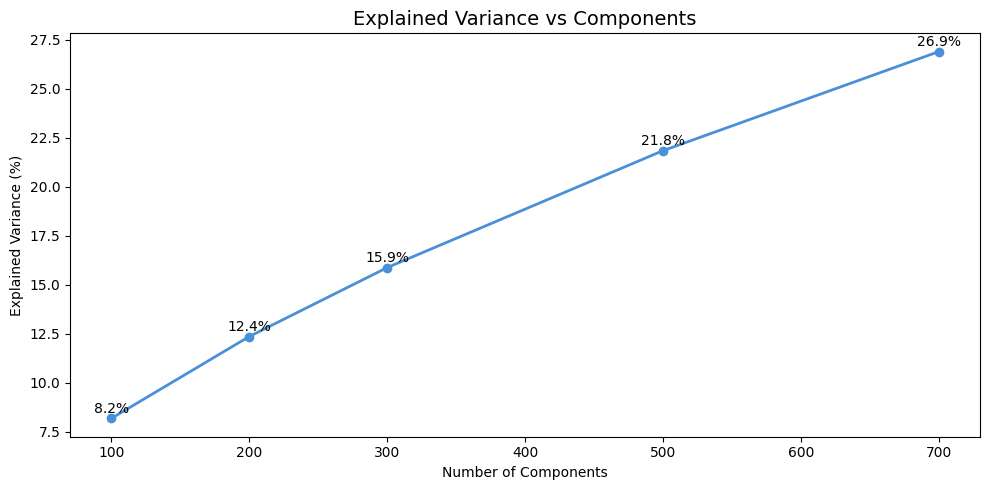

✅ Plot saved!


In [3]:
import matplotlib.pyplot as plt

components = [100, 200, 300, 500, 700]
variances  = []

for n in components:
    print(f"Testing n_components = {n}...")
    svd_test = TruncatedSVD(n_components=n, random_state=42, n_iter=10)
    svd_test.fit_transform(user_item_matrix)
    var = svd_test.explained_variance_ratio_.sum() * 100
    variances.append(var)
    print(f"  Explained Variance: {var:.2f}%")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(components, variances, marker='o', color='#4A90D9', linewidth=2)
plt.title('Explained Variance vs Components', fontsize=14)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance (%)')
for x, y in zip(components, variances):
    plt.text(x, y + 0.3, f'{y:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('components_variance.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [4]:
print("Training final model with 500 components...")

svd = TruncatedSVD(
    n_components=500,
    random_state=42,
    n_iter=15
)

user_factors = svd.fit_transform(user_item_matrix)
item_factors = svd.components_.T

print(f"✅ Model trained!")
print(f"User Factors Shape : {user_factors.shape}")
print(f"Item Factors Shape : {item_factors.shape}")
print(f"Explained Variance : {svd.explained_variance_ratio_.sum()*100:.2f}%")

Training final model with 500 components...
✅ Model trained!
User Factors Shape : (19906, 500)
Item Factors Shape : (82023, 500)
Explained Variance : 21.90%


In [5]:
# ============================================
# User Category Profile
# ============================================
user_category_profile = df.groupby(
    ['User_ID', 'Category_ID'])['Score'].sum().reset_index()
user_category_profile.columns = ['User_ID', 'Category_ID', 'Category_Score']

# ============================================
# Hybrid Recommendation Function
# ============================================
def get_hybrid_recommendations(user_id, n=5, svd_weight=0.6, cat_weight=0.4):

    user_idx    = user_encoder.transform([user_id])[0]
    user_vector = user_factors[user_idx]
    user_norm   = user_vector / (np.linalg.norm(user_vector) + 1e-10)
    item_norms  = item_factors / (np.linalg.norm(item_factors, axis=1, keepdims=True) + 1e-10)
    svd_scores  = user_norm @ item_norms.T

    # Category Score
    user_cats = user_category_profile[
        user_category_profile['User_ID'] == user_id
    ].sort_values('Category_Score', ascending=False)['Category_ID'].values

    cat_scores = np.zeros(n_products)
    for cat in user_cats[:3]:
        cat_products = df[df['Category_ID'] == cat]['product_idx'].values
        cat_scores[cat_products] += 1

    if cat_scores.max() > 0:
        cat_scores = cat_scores / cat_scores.max()

    # Hybrid Score
    hybrid_scores = (svd_weight * svd_scores) + (cat_weight * cat_scores)

    # استبعاد المنتجات اللي شافها
    seen = df[df['User_ID'] == user_id]['product_idx'].values
    hybrid_scores[seen] = -1

    top_indices  = hybrid_scores.argsort()[::-1][:n]
    top_products = product_encoder.inverse_transform(top_indices)
    top_cats     = [
        df[df['product_idx'] == idx]['Category_ID'].iloc[0]
        if len(df[df['product_idx'] == idx]) > 0 else None
        for idx in top_indices
    ]

    return pd.DataFrame({
        'Product_ID'  : top_products,
        'Category_ID' : top_cats,
        'Hybrid_Score': hybrid_scores[top_indices].round(4)
    })

# ============================================
# Test on sample users
# ============================================
print("=== Sample Recommendations ===")
for user in df['User_ID'].sample(3, random_state=42).values:
    print(f"\nUser {user}:")
    print(get_hybrid_recommendations(user))

=== Sample Recommendations ===

User 915552:
   Product_ID  Category_ID  Hybrid_Score
0     2842934      4145813        0.7571
1     4636662      4181361        0.7523
2     4736452      4145813        0.7355
3      880169      4145813        0.7194
4     1600835      4690421        0.6845

User 863432:
   Product_ID  Category_ID  Hybrid_Score
0     2120520      2520377        0.6990
1     4901875      2520377        0.6966
2     4229277      2520377        0.6813
3     3984117      2520377        0.6766
4     4088685      2520377        0.6688

User 859444:
   Product_ID  Category_ID  Hybrid_Score
0     2168532      3607361        0.8695
1     1930508      3607361        0.8616
2     1099134      3607361        0.8315
3     4992466      3607361        0.8231
4      242413      3607361        0.7988


In [6]:
# ============================================
# Time-based Split
# ============================================
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Train = قبل 1 ديسمبر
# Test  = بعد 1 ديسمبر
train_df = df[df['DateTime'] < '2017-12-01']
test_df  = df[df['DateTime'] >= '2017-12-01']

# نأخذ بس الـ buy من الـ test
test_buy = test_df[test_df['Behavior'] == 'buy']

print(f"Train interactions : {len(train_df):,}")
print(f"Test interactions  : {len(test_df):,}")
print(f"Test buy           : {len(test_buy):,}")
print(f"Test buy users     : {test_buy['User_ID'].nunique():,}")

Train interactions : 664,453
Test interactions  : 261,986
Test buy           : 5,766
Test buy users     : 3,880


In [7]:
# ============================================
# Fast Category-Based Evaluation
# ============================================
def evaluate_by_category_fast(test_data, k=5, sample_users=1000):
    precisions = []
    recalls    = []

    test_users = test_data['User_ID'].unique()
    test_users = pd.Series(test_users).sample(
        n=min(sample_users, len(test_users)),
        random_state=42
    ).values

    for user_id in test_users:
        actual_cats = set(
            test_data[test_data['User_ID'] == user_id]['Category_ID'].values
        )

        try:
            recs = get_hybrid_recommendations(user_id, n=k)
            recommended_cats = set(recs['Category_ID'].values)
        except:
            continue

        precision = len(actual_cats & recommended_cats) / k
        recall    = len(actual_cats & recommended_cats) / len(actual_cats) if actual_cats else 0

        precisions.append(precision)
        recalls.append(recall)

    avg_p = np.mean(precisions)
    avg_r = np.mean(recalls)

    return {
        'Precision@K'    : avg_p,
        'Recall@K'       : avg_r,
        'F1@K'           : 2 * avg_p * avg_r / (avg_p + avg_r + 1e-10),
        'Users evaluated': len(precisions)
    }

# ============================================
# Evaluate with Different K values
# ============================================
print("=== Time-based Category Evaluation ===")
for k in [5, 10, 20]:
    results = evaluate_by_category_fast(test_buy, k=k, sample_users=1000)
    print(f"\nK = {k}:")
    print(f"  Precision@{k}   : {results['Precision@K']*100:.2f}%")
    print(f"  Recall@{k}      : {results['Recall@K']*100:.2f}%")
    print(f"  F1@{k}          : {results['F1@K']:.4f}")
    print(f"  Users evaluated : {results['Users evaluated']:,}")

=== Time-based Category Evaluation ===

K = 5:
  Precision@5   : 12.78%
  Recall@5      : 47.55%
  F1@5          : 0.2015
  Users evaluated : 1,000

K = 10:
  Precision@10   : 7.48%
  Recall@10      : 55.75%
  F1@10          : 0.1319
  Users evaluated : 1,000

K = 20:
  Precision@20   : 4.17%
  Recall@20      : 61.97%
  F1@20          : 0.0782
  Users evaluated : 1,000


In [8]:
# ============================================
# Baseline: Popularity Model
# ============================================

# أكثر 20 category مشهورة بالـ train
top_categories = train_df['Category_ID'].value_counts().head(20).index.tolist()

# أكثر 20 منتج مشهور بالـ train  
top_products = train_df['Product_ID'].value_counts().head(20).index.tolist()

def evaluate_popularity_baseline(test_data, k=5, sample_users=1000):
    precisions = []
    recalls    = []

    test_users = pd.Series(test_data['User_ID'].unique()).sample(
        n=min(sample_users, test_data['User_ID'].nunique()),
        random_state=42
    ).values

    for user_id in test_users:
        actual_cats = set(
            test_data[test_data['User_ID'] == user_id]['Category_ID'].values
        )

        # اقتراح أشهر K category
        recommended_cats = set(top_categories[:k])

        precision = len(actual_cats & recommended_cats) / k
        recall    = len(actual_cats & recommended_cats) / len(actual_cats) if actual_cats else 0

        precisions.append(precision)
        recalls.append(recall)

    avg_p = np.mean(precisions)
    avg_r = np.mean(recalls)

    return {
        'Precision@K'    : avg_p,
        'Recall@K'       : avg_r,
        'F1@K'           : 2 * avg_p * avg_r / (avg_p + avg_r + 1e-10),
        'Users evaluated': len(precisions)
    }

# ============================================
# Compare Popularity vs Hybrid
# ============================================
print("=== Baseline vs Hybrid Model ===\n")

for k in [5, 10, 20]:
    pop     = evaluate_popularity_baseline(test_buy, k=k, sample_users=1000)
    hybrid  = evaluate_by_category_fast(test_buy, k=k, sample_users=1000)

    print(f"K = {k}:")
    print(f"  {'':20} {'Popularity':>12} {'Hybrid':>12}")
    print(f"  {'Precision':20} {pop['Precision@K']*100:>11.2f}% {hybrid['Precision@K']*100:>11.2f}%")
    print(f"  {'Recall':20} {pop['Recall@K']*100:>11.2f}% {hybrid['Recall@K']*100:>11.2f}%")
    print(f"  {'F1':20} {pop['F1@K']:>12.4f} {hybrid['F1@K']:>12.4f}")
    print()

=== Baseline vs Hybrid Model ===

K = 5:
                         Popularity       Hybrid
  Precision                   2.28%       12.78%
  Recall                      8.26%       47.55%
  F1                         0.0357       0.2015

K = 10:
                         Popularity       Hybrid
  Precision                   2.05%        7.48%
  Recall                     14.34%       55.75%
  F1                         0.0359       0.1319

K = 20:
                         Popularity       Hybrid
  Precision                   1.59%        4.17%
  Recall                     22.48%       61.97%
  F1                         0.0297       0.0782



In [9]:
import pickle

with open('hybrid_model_final.pkl', 'wb') as f:
    pickle.dump({
        'svd'                   : svd,
        'user_factors'          : user_factors,
        'item_factors'          : item_factors,
        'user_encoder'          : user_encoder,
        'product_encoder'       : product_encoder,
        'category_encoder'      : category_encoder,
        'user_category_profile' : user_category_profile
    }, f)

print("✅ Final model saved!")

✅ Final model saved!


In [3]:
import pickle
import numpy as np
import pandas as pd

with open('hybrid_model_final.pkl', 'rb') as f:
    model = pickle.load(f)

df = pd.read_csv('smart_filtered.csv')

# نحفظ بس user_category_profile والـ encoders
# وnumpy arrays مضغوطة
np.save('user_factors.npy', model['user_factors'][:, :100])
np.save('item_factors.npy', model['item_factors'][:, :100])

# احفظ الـ encoders والـ profile بشكل منفصل
with open('encoders.pkl', 'wb') as f:
    pickle.dump({
        'user_encoder'          : model['user_encoder'],
        'product_encoder'       : model['product_encoder'],
        'category_encoder'      : model['category_encoder'],
        'user_category_profile' : model['user_category_profile']
    }, f)

print("✅ Files saved!")

✅ Files saved!
